---
title: "Sesi 2: Analisis Regresi"
subtitle: "ISEI Workshop: Analisis Regresi & SEM dengan RStudio"
jupyter: ir
execute:
  warning: false
  message: false
---

# Pengantar Regresi Linear

### Rencana Hari Ini

**Bagian 1: Regresi Linear Sederhana**

- Konsep regresi dan korelasi
- Membangun model regresi sederhana
- Interpretasi koefisien

**Bagian 2: Regresi Linear Berganda**

- Menambahkan prediktor
- Perbandingan model dengan ANOVA
- Asumsi dan diagnostik

**Bagian 3: Variabel Kategorikal dan Pelaporan**

- Dummy variable
- Interaksi
- Pelaporan hasil

---

**Regresi** adalah metode statistik untuk memodelkan hubungan antara variabel dependen (Y) dan satu atau lebih variabel independen (X).

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p + \varepsilon$$

| Komponen | Simbol | Makna |
|----------|--------|-------|
| Intercept | $\beta_0$ | Nilai Y ketika semua X = 0 |
| Slope | $\beta_k$ | Perubahan Y untuk setiap kenaikan 1 unit $X_k$ |
| Error | $\varepsilon$ | Selisih antara nilai prediksi dan nilai aktual |

**Tujuan OLS**: Menemukan garis "terbaik" yang meminimalkan jumlah kuadrat error (Ordinary Least Squares).

### Apa yang Diestimasi oleh Regresi?

- **Variabel dependen (Y)**: outcome yang ingin dijelaskan atau diprediksi
- **Variabel independen (X)**: prediktor yang digunakan untuk menjelaskan Y
- Di R, model linear umumnya dibuat dengan fungsi `lm()` menggunakan formula seperti `Y ~ X1 + X2 + X3`
- Simbol `~` dibaca sebagai **"diprediksi oleh"**, sedangkan tanda `+` berarti **menambahkan prediktor ke model**

Secara praktis, regresi membantu kita menjawab dua pertanyaan sekaligus: **seberapa kuat hubungan antar variabel** dan **seberapa baik prediktor menjelaskan variasi outcome**.

### Korelasi vs Regresi

- **Korelasi**: mengukur kekuatan dan arah hubungan linear (simetris: $r_{xy} = r_{yx}$)
- **Regresi**: memprediksi nilai Y berdasarkan X (tidak simetris)
- Korelasi **bukan** kausalitas!

### Asumsi Regresi Linear

1. **Linearitas**: hubungan antara X dan Y linear
2. **Independensi**: residual saling independen
3. **Homoskedastisitas**: varians residual konstan
4. **Normalitas**: residual berdistribusi normal
5. **Multikolinearitas**: prediktor tidak terlalu berkorelasi satu sama lain

---

## 1. Persiapan

In [2]:
library(tidyverse)
library(readxl)
library(broom)
library(car)
library(lmtest)
library(sandwich)
library(knitr)

set.seed(2026)

── Attaching core tidyverse packages ─
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘ggplot2’ was built under R version 4.5.3 
Warning message:
package ‘broom’ was built under R version 4.5.2 


Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

The following object is masked from ‘package:purrr’:

    some

Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Warning messages:
1: package ‘lmtest’ was built under R version 4.5.2 
2: package ‘zoo’ was built under R version 4.5.3 
Warning message:
package ‘sandwich’ was built under R version 4.5.2 


## 2. Landasan Teori

Analisis ini didasarkan pada kerangka teori berikut:

- **Subjective Well-Being (SWB)**: Diener et al. (1999) mendefinisikan SWB sebagai evaluasi kognitif dan afektif seseorang terhadap kehidupannya, yang mencakup kepuasan hidup secara keseluruhan, emosi positif, dan rendahnya emosi negatif.
- **Kebebasan dan Kesejahteraan**: Inglehart (2000) dan Sen (1999) menunjukkan bahwa kebebasan memilih (*freedom of choice*) merupakan prediktor penting bagi kesejahteraan subjektif, terutama di masyarakat yang telah mencapai tingkat keamanan eksistensial tertentu.
- **Justifikasi variabel**: Pemilihan variabel prediktor (kepuasan finansial, kebebasan memilih, religiusitas) didasarkan pada literatur WVS yang secara konsisten menemukan hubungan signifikan antara faktor-faktor tersebut dengan kepuasan hidup.

::: {.callout-note}
## Catatan: Skala Ordinal sebagai Kontinu

Variabel dependen dan beberapa prediktor dalam dataset ini diukur menggunakan skala Likert 1–10. Norman (2010) menunjukkan bahwa data ordinal dengan skala yang cukup lebar (≥ 5 poin) dapat diperlakukan sebagai data kontinu dalam analisis parametrik tanpa menimbulkan bias yang berarti.
:::

## 3. Import & Pembersihan Data

Data **World Values Survey (WVS)** Wave 7 yang sudah diterjemahkan ke Bahasa Indonesia.

In [3]:
wvs <- read_excel("data/regresi/wvs1.xlsx")
glimpse(wvs)

Rows: 7,087
Columns: 16
$ negara                 <chr> "Kana…
$ id_responden           <dbl> 12407…
$ pentingnya_keluarga    <dbl> 1, 1,…
$ pentingnya_teman       <dbl> 1, 1,…
$ pentingnya_waktu_luang <dbl> 1, 2,…
$ pentingnya_pekerjaan   <dbl> 1, 1,…
$ kebebasan_memilih      <dbl> 7, 5,…
$ kepuasan_hidup         <dbl> 5, 8,…
$ kepuasan_finansial     <dbl> 8, 2,…
$ religiusitas           <dbl> 9, 10…
$ skala_politik          <dbl> 10, 5…
$ jenis_kelamin          <chr> "Pere…
$ tahun_lahir            <dbl> 1944,…
$ usia                   <dbl> 76, 6…
$ status_pernikahan      <chr> "Pisa…
$ status_pekerjaan       <chr> "Pens…


### Variabel Utama

| Variabel | Deskripsi | Tipe |
|----------|-----------|------|
| `kepuasan_hidup` | Kepuasan hidup (1–10) | Numerik |
| `kepuasan_finansial` | Kepuasan finansial (1–10) | Numerik |
| `kebebasan_memilih` | Kebebasan memilih (1–10) | Numerik |
| `religiusitas` | Tingkat religiusitas (1–10) | Numerik |
| `usia` | Usia responden | Numerik |
| `jenis_kelamin` | Laki-laki / Perempuan | Kategorikal |
| `negara` | Negara responden | Kategorikal |

In [4]:
dat <- wvs |>
  select(kepuasan_hidup, kebebasan_memilih, kepuasan_finansial, usia,
         religiusitas, jenis_kelamin, negara) |>
  drop_na()

nrow(dat)

[1] 6922

---

# Bagian 1: Regresi Linear Sederhana

## 4. Korelasi

Sebelum regresi, periksa korelasi bivariat:

In [5]:
cor(dat$kepuasan_finansial, dat$kepuasan_hidup)

[1] 0.6472145

In [6]:
cor.test(dat$kepuasan_finansial, dat$kepuasan_hidup)


	Pearson's product-moment
	correlation

data:  dat$kepuasan_finansial and dat$kepuasan_hidup
t = 70.627, df = 6920, p-value <
2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6333125 0.6606990
sample estimates:
      cor 
0.6472145 


**Interpretasi:** `cor.test()` menguji signifikansi korelasi Pearson. Korelasi antara kepuasan finansial dan kepuasan hidup adalah $r = 0.647$ ($p < .001$), menunjukkan hubungan positif yang kuat — semakin tinggi kepuasan finansial, semakin tinggi kepuasan hidup.

## 5. Regresi Linear Sederhana (M1)

$$\text{kepuasan\_hidup} = \beta_0 + \beta_1 \cdot \text{kepuasan\_finansial} + \varepsilon$$

Fungsi `lm()` adalah singkatan dari **linear model**. Formula `kepuasan_hidup ~ kepuasan_finansial` dibaca sebagai: **kepuasan hidup diprediksi oleh kepuasan finansial**.

In [7]:
m1 <- lm(kepuasan_hidup ~ kepuasan_finansial, data = dat)
tidy(m1, conf.int = TRUE)

# A tibble: 2 × 7
  term    estimate std.error statistic
  <chr>      <dbl>     <dbl>     <dbl>
1 (Inter…    3.51    0.0535       65.7
2 kepuas…    0.545   0.00772      70.6
# ℹ 3 more variables: p.value <dbl>,
#   conf.low <dbl>, conf.high <dbl>

**Interpretasi:** `tidy()` dari paket broom mengekstrak koefisien regresi ke dalam tibble. Intercept = 3.51 (prediksi kepuasan hidup jika kepuasan finansial = 0). Slope = 0.545 artinya setiap kenaikan 1 poin kepuasan finansial meningkatkan kepuasan hidup sebesar 0.545 poin ($p < .001$).

Untuk melihat ringkasan lengkap model, gunakan `summary()`:

In [8]:
summary(m1)


Call:
lm(formula = kepuasan_hidup ~ kepuasan_finansial, data = dat)

Residuals:
    Min      1Q  Median      3Q 
-7.9603 -0.7807  0.1295  0.7641 
    Max 
 5.9437 

Coefficients:
                   Estimate
(Intercept)        3.511402
kepuasan_finansial 0.544890
                   Std. Error t value
(Intercept)          0.053484   65.65
kepuasan_finansial   0.007715   70.63
                   Pr(>|t|)    
(Intercept)          <2e-16 ***
kepuasan_finansial   <2e-16 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.392 on 6920 degrees of freedom
Multiple R-squared:  0.4189,	Adjusted R-squared:  0.4188 
F-statistic:  4988 on 1 and 6920 DF,  p-value: < 2.2e-16


### Membaca Output `summary()`

Jika Anda menjalankan `summary(m1)`, output terdiri dari:

1. **Call**: formula model yang digunakan
2. **Residuals**: ringkasan distribusi residual (median mendekati 0 = baik)
3. **Coefficients**:
   - `Estimate`: nilai koefisien ($\beta$)
   - `Std. Error`: standard error koefisien
   - `t value`: statistik uji ($\beta / SE$)
   - `Pr(>|t|)`: p-value (signifikan jika < 0.05)
4. **R-squared**: proporsi varians yang dijelaskan model
5. **F-statistic**: uji signifikansi keseluruhan model

**Interpretasi**:

- **Intercept** ($\beta_0$): Ketika `kepuasan_finansial` = 0, rata-rata `kepuasan_hidup` adalah nilai intercept.
- **Slope** ($\beta_1$): Setiap kenaikan 1 poin `kepuasan_finansial`, `kepuasan_hidup` meningkat sebesar $\beta_1$ poin.

### R-squared

In [9]:
glance(m1) |> select(r.squared, adj.r.squared, AIC)

# A tibble: 1 × 3
  r.squared adj.r.squared    AIC
      <dbl>         <dbl>  <dbl>
1     0.419         0.419 24222.

*glance()* memberikan ringkasan statistik model, termasuk $R^2$, $R^2$ adjusted, dan AIC.

$R^2$ = proporsi varians variabel dependen yang dijelaskan oleh model. Rentang: 0 (tidak menjelaskan) sampai 1 (sempurna). $R^2$ adjusted disesuaikan dengan jumlah prediktor.

### Visualisasi M1

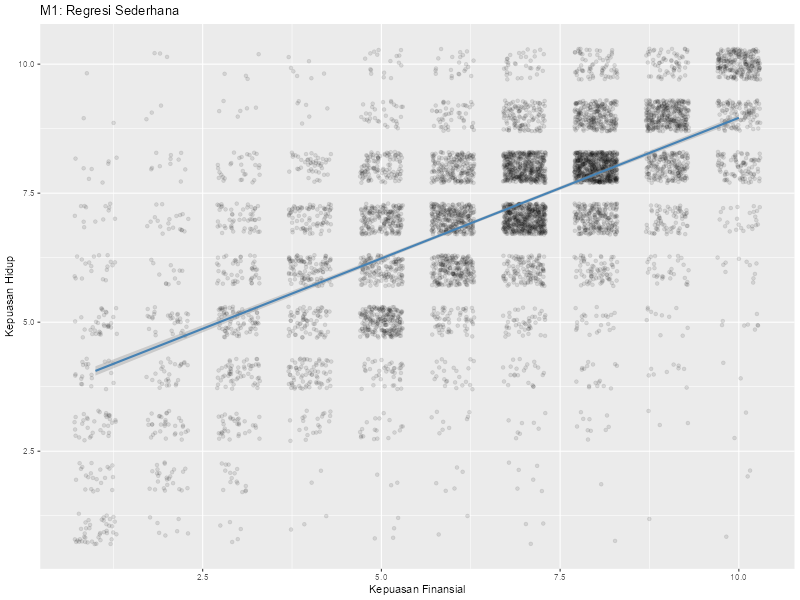

`geom_smooth()` using formula = 'y ~
x'

In [10]:
ggplot(dat, aes(x = kepuasan_finansial, y = kepuasan_hidup)) +
  geom_jitter(alpha = 0.1, width = 0.3, height = 0.3) +
  geom_smooth(method = "lm", color = "steelblue") +
  labs(title = "M1: Regresi Sederhana",
       x = "Kepuasan Finansial", y = "Kepuasan Hidup")

---

# Bagian 2: Regresi Linear Berganda

## 6. Model dengan 2 Prediktor (M2)

Model sederhana hanya menggunakan **satu** prediktor. Namun dalam realita, banyak faktor mempengaruhi suatu outcome. Regresi berganda memungkinkan kita:

- **Mengontrol** variabel lain (confounders)
- Melihat **kontribusi unik** setiap prediktor
- Meningkatkan **prediksi**

Formula umum:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p + \varepsilon$$

Di R: `lm(Y ~ X1 + X2 + X3, data = ...)` — tanda `+` menambahkan prediktor (bukan operasi matematika).

Regresi berganda memungkinkan kita mengontrol variabel lain (confounders) dan melihat kontribusi unik setiap prediktor.

In [11]:
m2 <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih,
         data = dat)
tidy(m2, conf.int = TRUE)

# A tibble: 3 × 7
  term    estimate std.error statistic
  <chr>      <dbl>     <dbl>     <dbl>
1 (Inter…    1.71    0.0648       26.3
2 kepuas…    0.388   0.00788      49.2
3 kebeba…    0.388   0.00940      41.3
# ℹ 3 more variables: p.value <dbl>,
#   conf.low <dbl>, conf.high <dbl>

**Interpretasi:** Dengan dua prediktor, kepuasan finansial ($B = 0.388$) dan kebebasan memilih ($B = 0.388$) sama-sama signifikan ($p < .001$). Kontribusi keduanya hampir setara. $R^2_{adj}$ meningkat dari 0.419 (M1) menjadi 0.534 (M2) — penambahan kebebasan memilih menjelaskan 11.5% varians tambahan.

::: {.callout-important}
Setiap koefisien diinterpretasikan **"dengan mengontrol variabel lain"** (ceteris paribus). Contoh: "Setiap kenaikan 1 poin kepuasan finansial, kepuasan hidup meningkat sebesar β poin, **setelah mengontrol kebebasan memilih**."
:::

In [12]:
summary(m2)


Call:
lm(formula = kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih, 
    data = dat)

Residuals:
    Min      1Q  Median      3Q 
-6.9196 -0.5901  0.0804  0.6922 
    Max 
 5.9629 

Coefficients:
                   Estimate
(Intercept)        1.707688
kepuasan_finansial 0.388234
kebebasan_memilih  0.388250
                   Std. Error t value
(Intercept)          0.064836   26.34
kepuasan_finansial   0.007884   49.24
kebebasan_memilih    0.009403   41.29
                   Pr(>|t|)    
(Intercept)          <2e-16 ***
kepuasan_finansial   <2e-16 ***
kebebasan_memilih    <2e-16 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.246 on 6919 degrees of freedom
Multiple R-squared:  0.5338,	Adjusted R-squared:  0.5336 
F-statistic:  3961 on 2 and 6919 DF,  p-value: < 2.2e-16


## 7. Regresi Berganda Penuh (M3)

In [13]:
m3 <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
           religiusitas + usia, data = dat)
tidy(m3, conf.int = TRUE)

# A tibble: 5 × 7
  term    estimate std.error statistic
  <chr>      <dbl>     <dbl>     <dbl>
1 (Inter…  1.31     0.0781       16.8 
2 kepuas…  0.379    0.00792      47.9 
3 kebeba…  0.389    0.00935      41.6 
4 religi…  0.0323   0.00578       5.59
5 usia     0.00569  0.000894      6.37
# ℹ 3 more variables: p.value <dbl>,
#   conf.low <dbl>, conf.high <dbl>

In [14]:
summary(m3)


Call:
lm(formula = kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih + 
    religiusitas + usia, data = dat)

Residuals:
    Min      1Q  Median      3Q 
-6.9427 -0.5923  0.0680  0.6828 
    Max 
 6.0696 

Coefficients:
                    Estimate
(Intercept)        1.3138839
kepuasan_finansial 0.3792150
kebebasan_memilih  0.3890755
religiusitas       0.0322855
usia               0.0056928
                   Std. Error t value
(Intercept)         0.0781243  16.818
kepuasan_finansial  0.0079218  47.870
kebebasan_memilih   0.0093512  41.607
religiusitas        0.0057781   5.588
usia                0.0008938   6.369
                   Pr(>|t|)    
(Intercept)         < 2e-16 ***
kepuasan_finansial  < 2e-16 ***
kebebasan_memilih   < 2e-16 ***
religiusitas       2.39e-08 ***
usia               2.02e-10 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.24 on 6917 degrees of freedom
Multiple R-squared:  0.5391,	Adjusted R-squared: 

**Interpretasi M3:** Semua 4 prediktor signifikan ($p < .001$). Kepuasan finansial ($B = 0.379$) dan kebebasan memilih ($B = 0.389$) tetap dominan. Religiusitas ($B = 0.032$) dan usia ($B = 0.006$) signifikan namun efeknya kecil. $R^2_{adj} = 0.539$ — model menjelaskan ~54% varians kepuasan hidup.

---

# Bagian 3: Variabel Kategorikal dan Interaksi

## 8. Regresi dengan Variabel Kategorikal (M4)

R secara otomatis membuat **dummy variables** dari faktor. Kategori referensi: level pertama (alfabet). Koefisien dummy menunjukkan perbedaan rata-rata dibanding referensi.

Artinya, jika `jenis_kelamin` memiliki dua kategori, R akan memilih satu kategori sebagai **baseline** dan koefisien untuk kategori lainnya dibaca sebagai selisih terhadap baseline tersebut, dengan prediktor lain dianggap konstan.

In [15]:
dat <- dat |>
  mutate(
    jenis_kelamin = factor(jenis_kelamin),
    negara = factor(negara)
  )

levels(dat$jenis_kelamin)
levels(dat$negara)

[1] "Kanada"        "Selandia Baru"
[3] "Singapura"    

In [16]:
m4 <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
           religiusitas + usia + jenis_kelamin, data = dat)
tidy(m4, conf.int = TRUE)

# A tibble: 6 × 7
  term    estimate std.error statistic
  <chr>      <dbl>     <dbl>     <dbl>
1 (Inter…  1.29     0.0797       16.2 
2 kepuas…  0.379    0.00792      47.9 
3 kebeba…  0.389    0.00935      41.6 
4 religi…  0.0319   0.00579       5.50
5 usia     0.00578  0.000896      6.45
6 jenis_…  0.0403   0.0299        1.35
# ℹ 3 more variables: p.value <dbl>,
#   conf.low <dbl>, conf.high <dbl>

**Interpretasi M4:** Koefisien `jenis_kelaminPerempuan` = 0.040 ($p = .178$) **tidak signifikan**. Artinya, setelah mengontrol variabel lain, tidak ada perbedaan kepuasan hidup yang bermakna antara laki-laki dan perempuan. $R^2_{adj}$ praktis tidak berubah (0.539).

**Interpretasi**: Koefisien `jenis_kelaminPerempuan` menunjukkan perbedaan rata-rata kepuasan hidup antara Perempuan dan Laki-laki (referensi), setelah mengontrol variabel lain.

In [17]:
summary(m4)


Call:
lm(formula = kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih + 
    religiusitas + usia + jenis_kelamin, data = dat)

Residuals:
    Min      1Q  Median      3Q 
-6.9213 -0.5937  0.0663  0.6855 
    Max 
 6.0900 

Coefficients:
                        Estimate
(Intercept)            1.2925679
kepuasan_finansial     0.3793340
kebebasan_memilih      0.3887850
religiusitas           0.0318536
usia                   0.0057807
jenis_kelaminPerempuan 0.0403478
                       Std. Error
(Intercept)             0.0797037
kepuasan_finansial      0.0079218
kebebasan_memilih       0.0093531
religiusitas            0.0057866
usia                    0.0008961
jenis_kelaminPerempuan  0.0299278
                       t value
(Intercept)             16.217
kepuasan_finansial      47.885
kebebasan_memilih       41.567
religiusitas             5.505
usia                     6.451
jenis_kelaminPerempuan   1.348
                       Pr(>|t|)    
(Intercept)             < 2e-16 ***

## 9. Model dengan Negara (M5)

In [18]:
m5 <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
           religiusitas + usia + jenis_kelamin + negara, data = dat)
tidy(m5, conf.int = TRUE) |> kable(digits = 3)



|term                   | estimate| std.error| statistic| p.value| conf.low| conf.high|
|:----------------------|--------:|---------:|---------:|-------:|--------:|---------:|
|(Intercept)            |    1.256|     0.081|    15.541|   0.000|    1.098|     1.414|
|kepuasan_finansial     |    0.377|     0.008|    47.548|   0.000|    0.361|     0.392|
|kebebasan_memilih      |    0.394|     0.009|    41.623|   0.000|    0.376|     0.413|
|religiusitas           |    0.028|     0.006|     4.679|   0.000|    0.016|     0.039|
|usia                   |    0.005|     0.001|     5.781|   0.000|    0.003|     0.007|
|jenis_kelaminPerempuan |    0.031|     0.030|     1.028|   0.304|   -0.028|     0.090|
|negaraSelandia Baru    |    0.151|     0.046|     3.275|   0.001|    0.060|     0.241|
|negaraSingapura        |    0.156|     0.035|     4.427|   0.000|    0.087|     0.225|

**Interpretasi M5:** Dengan Kanada sebagai referensi, Selandia Baru ($B = 0.151, p = .001$) dan Singapura ($B = 0.156, p < .001$) memiliki kepuasan hidup yang sedikit lebih tinggi, ceteris paribus. Jenis kelamin tetap tidak signifikan ($p = .304$).

### Mengubah Kategori Referensi

Gunakan `relevel()` untuk mengubah kategori referensi:

In [19]:
dat <- dat |>
  mutate(negara = relevel(negara, ref = "Singapura"))

m5b <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
            religiusitas + usia + jenis_kelamin + negara, data = dat)
tidy(m5b, conf.int = TRUE) |> kable(digits = 3)



|term                   | estimate| std.error| statistic| p.value| conf.low| conf.high|
|:----------------------|--------:|---------:|---------:|-------:|--------:|---------:|
|(Intercept)            |    1.412|     0.083|    16.969|   0.000|    1.249|     1.575|
|kepuasan_finansial     |    0.377|     0.008|    47.548|   0.000|    0.361|     0.392|
|kebebasan_memilih      |    0.394|     0.009|    41.623|   0.000|    0.376|     0.413|
|religiusitas           |    0.028|     0.006|     4.679|   0.000|    0.016|     0.039|
|usia                   |    0.005|     0.001|     5.781|   0.000|    0.003|     0.007|
|jenis_kelaminPerempuan |    0.031|     0.030|     1.028|   0.304|   -0.028|     0.090|
|negaraKanada           |   -0.156|     0.035|    -4.427|   0.000|   -0.225|    -0.087|
|negaraSelandia Baru    |   -0.005|     0.051|    -0.104|   0.917|   -0.105|     0.094|

## 10. Model dengan Interaksi (M6)

Interaksi: efek satu variabel **tergantung** pada level variabel lain.

Jika interaksi signifikan, maka slope hubungan `kepuasan_finansial` terhadap `kepuasan_hidup` **berbeda antar kelompok** `jenis_kelamin`. Dengan kata lain, pengaruh satu prediktor tidak lagi konstan untuk semua responden.

In [20]:
m6 <- lm(kepuasan_hidup ~ kepuasan_finansial * jenis_kelamin +
           kebebasan_memilih + religiusitas + usia, data = dat)
tidy(m6, conf.int = TRUE) |> kable(digits = 3)



|term                                      | estimate| std.error| statistic| p.value| conf.low| conf.high|
|:-----------------------------------------|--------:|---------:|---------:|-------:|--------:|---------:|
|(Intercept)                               |    1.198|     0.092|    13.075|   0.000|    1.018|     1.377|
|kepuasan_finansial                        |    0.394|     0.011|    37.055|   0.000|    0.373|     0.415|
|jenis_kelaminPerempuan                    |    0.231|     0.095|     2.418|   0.016|    0.044|     0.418|
|kebebasan_memilih                         |    0.388|     0.009|    41.504|   0.000|    0.370|     0.407|
|religiusitas                              |    0.032|     0.006|     5.488|   0.000|    0.020|     0.043|
|usia                                      |    0.006|     0.001|     6.469|   0.000|    0.004|     0.008|
|kepuasan_finansial:jenis_kelaminPerempuan |   -0.029|     0.014|    -2.101|   0.036|   -0.056|    -0.002|

**Interpretasi M6:** Interaksi `kepuasan_finansial:jenis_kelaminPerempuan` = −0.029 ($p = .036$) signifikan. Artinya, efek kepuasan finansial terhadap kepuasan hidup sedikit **lebih lemah** pada perempuan dibanding laki-laki. Namun besarannya sangat kecil secara praktis.

### Visualisasi Interaksi

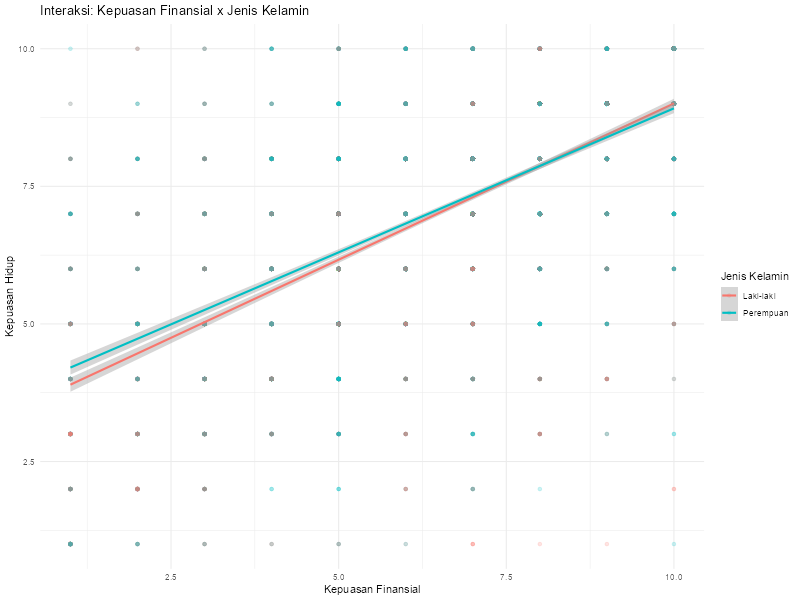

`geom_smooth()` using formula = 'y ~
x'

In [21]:
ggplot(dat, aes(x = kepuasan_finansial, y = kepuasan_hidup,
                color = jenis_kelamin)) +
  geom_point(alpha = 0.2) +
  geom_smooth(method = "lm") +
  labs(title = "Interaksi: Kepuasan Finansial x Jenis Kelamin",
       x = "Kepuasan Finansial", y = "Kepuasan Hidup",
       color = "Jenis Kelamin") +
  theme_minimal()

---

# Bagian 4: Diagnostik dan Perbandingan Model

## 11. Perbandingan Model

### ANOVA

Apakah model yang lebih kompleks secara signifikan lebih baik?

In [22]:
anova(m1, m2, m3)

Analysis of Variance Table

Model 1: kepuasan_hidup ~ kepuasan_finansial
Model 2: kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih
Model 3: kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih + religiusitas + 
    usia
  Res.Df   RSS Df Sum of Sq        F
1   6920 13399                      
2   6919 10750  1   2648.89 1724.066
3   6917 10627  2    122.78   39.956
     Pr(>F)    
1              
2 < 2.2e-16 ***
3 < 2.2e-16 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

**Interpretasi ANOVA**: RSS (Residual Sum of Squares) semakin kecil = lebih baik. F statistic menguji apakah penambahan variabel signifikan. Jika p-value < 0.05, model yang lebih kompleks **signifikan lebih baik** dari model sebelumnya.

ANOVA untuk perbandingan model hanya tepat jika model bersifat **nested**, yaitu model yang lebih sederhana merupakan bagian dari model yang lebih kompleks.

### Tabel Perbandingan (dengan Cohen's f²)

Cohen's $f^2$ mengukur effect size untuk regresi. Interpretasi: 0.02 = kecil, 0.15 = sedang, 0.35 = besar (Cohen, 1988).

In [23]:
r2_adj <- c(glance(m1)$adj.r.squared, glance(m2)$adj.r.squared,
            glance(m3)$adj.r.squared, glance(m4)$adj.r.squared,
            glance(m5)$adj.r.squared, glance(m6)$adj.r.squared)

cohens_f2 <- c(NA, diff(r2_adj) / (1 - r2_adj[-1]))

tibble(
  Model = paste0("m", 1:6),
  Formula = c("finansial", "+ kebebasan", "+ religiusitas + usia",
              "+ jenis_kelamin", "+ negara", "finansial * jk + lainnya"),
  R2_adj = r2_adj,
  AIC = c(AIC(m1), AIC(m2), AIC(m3), AIC(m4), AIC(m5), AIC(m6)),
  Cohens_f2 = cohens_f2
) |> kable(digits = 3)



|Model |Formula                  | R2_adj|      AIC| Cohens_f2|
|:-----|:------------------------|------:|--------:|---------:|
|m1    |finansial                |  0.419| 24221.64|        NA|
|m2    |+ kebebasan              |  0.534| 22698.99|     0.246|
|m3    |+ religiusitas + usia    |  0.539| 22623.47|     0.011|
|m4    |+ jenis_kelamin          |  0.539| 22623.65|     0.000|
|m5    |+ negara                 |  0.540| 22602.88|     0.003|
|m6    |finansial * jk + lainnya |  0.539| 22621.24|    -0.003|

**Interpretasi:** Lompatan terbesar terjadi dari M1 ke M2 (Cohen's $f^2 = 0.246$, efek sedang-besar), menunjukkan kebebasan memilih adalah prediktor kunci. Penambahan variabel setelah M3 memberikan peningkatan marginal ($f^2 < 0.02$). **M5** (dengan negara) memiliki AIC terendah dan menjadi model terbaik secara parsimoni.

## 12. Diagnostik Model

### Diagnostic Plots

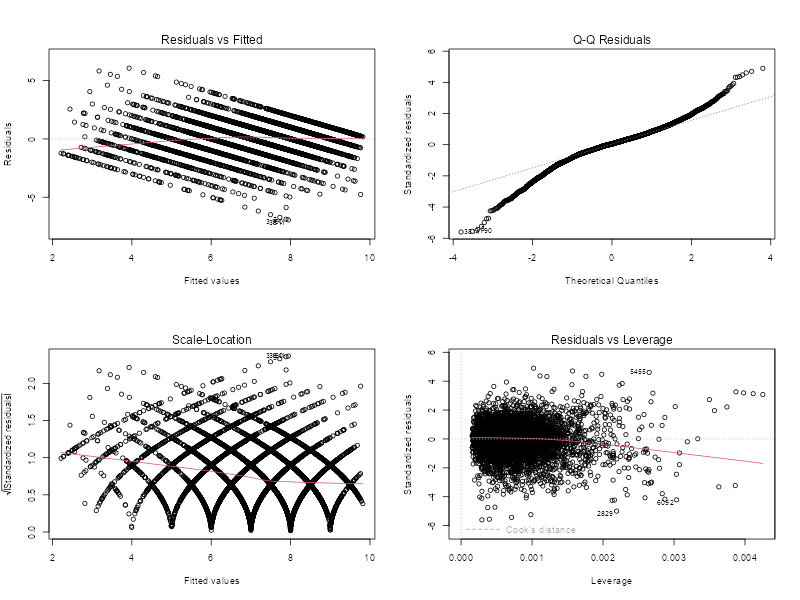

In [24]:
par(mfrow = c(2, 2))
plot(m3)

**Interpretasi Diagnostic Plots:**

1. **Residuals vs Fitted** (kiri atas): Memeriksa linearitas dan homoskedastisitas. Idealnya titik-titik menyebar acak di sekitar garis horizontal nol tanpa pola sistematis. Pola lengkung mengindikasikan hubungan non-linear; pola kipas mengindikasikan heteroskedastisitas.

2. **Normal Q-Q** (kanan atas): Memeriksa normalitas residual. Jika titik-titik mengikuti garis diagonal, residual berdistribusi mendekati normal. Deviasi di ujung (ekor) menunjukkan distribusi berekor tebal (*heavy-tailed*).

3. **Scale-Location** (kiri bawah): Memeriksa homoskedastisitas. Garis merah yang relatif datar menunjukkan varians residual konstan. Garis yang turun mengindikasikan varians menurun seiring fitted values. Pola jaring → kemungkinan y diskrit/ordinal.

4. **Residuals vs Leverage** (kanan bawah): Mengidentifikasi observasi berpengaruh (*influential*). Titik di luar garis Cook's distance (garis putus-putus) berpotensi mempengaruhi hasil regresi secara substansial.

### VIF (Variance Inflation Factor)

**VIF** mengukur seberapa besar varians koefisien meningkat akibat korelasi antar prediktor.

In [ ]:
# Uji Normalitas Residual (Kolmogorov-Smirnov)
ks.test(m3$residuals, "pnorm", mean = 0, sd = sd(m3$residuals))

# Uji Autokorelasi (Durbin-Watson)
dwtest(m3)
# Uji Autokorelasi (Durbin-Watson)
dwtest(m3)

kepuasan_finansial  kebebasan_memilih 
          1.328704           1.301577 
      religiusitas               usia 
          1.012549           1.036567 

- VIF < 5: tidak ada masalah
- VIF 5–10: perlu perhatian
- VIF > 10: multikolinearitas serius

### Uji Heteroskedastisitas (Breusch-Pagan)

Uji Formal

In [ ]:
bptest(m3)


	studentized Breusch-Pagan test

data:  m3
BP = 219.08, df = 4, p-value <
2.2e-16


Jika p-value < 0.05, terdapat indikasi **heteroskedastisitas** — varians residual tidak konstan.

In [32]:
# Uji Normalitas Residual (Kolmogorov-Smirnov)
ks_result <- ks.test(m3$residuals, "pnorm", mean = 0, sd = sd(m3$residuals))
ks_result

Warning message:
In ks.test.default(m3$residuals, "pnorm", mean = 0, sd = sd(m3$residuals)) :
  ties should not be present for the one-sample Kolmogorov-Smirnov test



	Asymptotic one-sample
	Kolmogorov-Smirnov test

data:  m3$residuals
D = 0.066964, p-value < 2.2e-16
alternative hypothesis: two-sided


In [33]:
# Uji Autokorelasi (Durbin-Watson)
dwtest(m3)


	Durbin-Watson test

data:  m3
DW = 1.9745, p-value = 0.1432
alternative hypothesis: true autocorrelation is greater than 0


**Interpretasi Uji Normalitas (Kolmogorov-Smirnov):** $D = 0.067$, $p < .001$ — secara statistik residual tidak berdistribusi normal. Namun pada sampel besar ($n = 6922$), uji ini sangat sensitif dan hampir selalu menolak $H_0$ meskipun deviasi kecil. Berdasarkan **Q-Q plot** sebelumnya, distribusi residual mendekati normal dengan sedikit deviasi di ekor — cukup memadai untuk regresi OLS.

**Interpretasi Durbin-Watson:** $DW = 1.975$, $p = .143$ — **tidak ada autokorelasi** yang signifikan. Nilai DW sangat mendekati 2, menunjukkan residual independen satu sama lain.

::: {.callout-note}
## Autokorelasi pada Data Cross-Section

Uji Durbin-Watson awalnya dirancang untuk **data time series**, di mana urutan observasi bermakna (misal: data bulanan). Pada **data cross-section** seperti survei WVS, urutan baris bersifat **arbitrer** — tidak ada alasan teoretis mengapa responden ke-100 harus berkorelasi dengan responden ke-99.

Meski demikian, autokorelasi pada data cross-section bisa muncul jika:

- Data diurutkan berdasarkan variabel tertentu (misal usia atau wilayah)
- Ada **clustering** yang tidak dimodelkan (misal responden dari kota yang sama)

Dalam konteks ini, hasil $DW = 1.975$ ($p = .143$) mengonfirmasi tidak ada pola sistematik dalam residual. Jika ada kekhawatiran clustering, solusi yang lebih tepat adalah **cluster-robust standard errors** daripada koreksi autokorelasi.
:::

### Robust Standard Errors

Jika terdapat heteroskedastisitas, gunakan **robust standard errors** (HC3) untuk inferensi yang lebih valid:

In [28]:
coeftest(m3, vcov = vcovHC(m3, type = "HC3"))


t test of coefficients:

                     Estimate
(Intercept)        1.31388387
kepuasan_finansial 0.37921502
kebebasan_memilih  0.38907553
religiusitas       0.03228555
usia               0.00569275
                   Std. Error t value
(Intercept)        0.08886323 14.7855
kepuasan_finansial 0.01134592 33.4230
kebebasan_memilih  0.01354804 28.7182
religiusitas       0.00580773  5.5591
usia               0.00093759  6.0717
                    Pr(>|t|)    
(Intercept)        < 2.2e-16 ***
kepuasan_finansial < 2.2e-16 ***
kebebasan_memilih  < 2.2e-16 ***
religiusitas       2.813e-08 ***
usia               1.333e-09 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1


**Interpretasi:** `coeftest()` dengan `vcovHC(, type = "HC3")` menghasilkan robust standard errors yang lebih besar dari OLS biasa (misal: kepuasan finansial SE naik dari 0.008 ke 0.011). Semua prediktor tetap signifikan, mengonfirmasi bahwa kesimpulan regresi **robust** terhadap heteroskedastisitas.

## Aturan praktis (applied economics)

| Situasi                                     | Rekomendasi                                      |
| ------------------------------------------- | ------------------------------------------------ |
| Cross-section, n > 250, no extreme leverage | HC1 atau HC3                                     |
| Cross-section, n < 100                      | **HC3** (default Long & Ervin)                   |
| Cross-section, leverage points mencurigakan | HC4                                              |
| Panel data (observations clustered by unit) | **Cluster-robust SE** (`vcovCL`, bukan HC biasa) |
| Time series dengan autocorrelation          | **HAC / Newey-West** (`vcovHAC`, `NeweyWest`)    |
| Panel + serial corr dalam unit              | **Driscoll-Kraay** atau cluster two-way          |
| Mau replicate paper Stata                   | HC1 (biar match `reg ..., robust`)               |
| Lagi ragu                                   | **HC3** — aman untuk mayoritas kasus             |

::: {.callout-tip}
Robust standard errors (HC3) memberikan estimasi SE yang valid meskipun terdapat heteroskedastisitas, sehingga p-value dan confidence interval lebih dapat dipercaya.
:::

Penting: robust SE **mengubah inferensi**, tetapi **tidak mengubah koefisien regresi**. Jadi nilai `B` tetap sama; yang berubah adalah standard error, statistik uji, dan p-value.

## 13. Standardized Coefficients

Untuk membandingkan kekuatan relatif antar prediktor, gunakan koefisien terstandarisasi:

In [29]:
dat_scaled <- dat |>
  mutate(across(where(is.numeric), scale))

m3_std <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
               religiusitas + usia, data = dat_scaled)
tidy(m3_std, conf.int = TRUE) |> kable(digits = 3)



|term               | estimate| std.error| statistic| p.value| conf.low| conf.high|
|:------------------|--------:|---------:|---------:|-------:|--------:|---------:|
|(Intercept)        |    0.000|     0.008|     0.000|       1|   -0.016|     0.016|
|kepuasan_finansial |    0.450|     0.009|    47.870|       0|    0.432|     0.469|
|kebebasan_memilih  |    0.387|     0.009|    41.607|       0|    0.369|     0.406|
|religiusitas       |    0.046|     0.008|     5.588|       0|    0.030|     0.062|
|usia               |    0.053|     0.008|     6.369|       0|    0.037|     0.069|

**Interpretasi:** Koefisien terstandarisasi menunjukkan kepuasan finansial ($\beta = 0.450$) memiliki pengaruh relatif terkuat, diikuti kebebasan memilih ($\beta = 0.387$). Religiusitas ($\beta = 0.046$) dan usia ($\beta = 0.053$) memiliki efek kecil. Kedua prediktor utama berkontribusi hampir setara terhadap kepuasan hidup.

**Interpretasi**: Koefisien terstandarisasi ($\beta$) menunjukkan perubahan dalam satuan standar deviasi. Prediktor dengan |$\beta$| terbesar memiliki pengaruh relatif terkuat.

---

# Pelaporan Hasil

### Tips Pelaporan

- Laporkan $R^2$ adjusted (bukan $R^2$ biasa)
- Gunakan **unstandardized** coefficients ($B$) ATAU **standardized** ($\beta$) — pilih satu dan konsisten
- Sertakan **95% CI** untuk setiap koefisien
- Laporkan F-test keseluruhan model
- Sebutkan jumlah observasi
- Jika ada variabel yang tidak signifikan, tetap laporkan

### Referensi

- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum.
- Diener, E., Suh, E. M., Lucas, R. E., & Smith, H. L. (1999). Subjective well-being: Three decades of progress. *Psychological Bulletin*, 125(2), 276–302.
- Inglehart, R. (2000). Globalization and postmodern values. *The Washington Quarterly*, 23(1), 215–228.
- Norman, G. (2010). Likert scales, levels of measurement and the "laws" of statistics. *Advances in Health Sciences Education*, 15(5), 625–632.

---

# Rekap Sesi 2

- **Regresi sederhana**: satu prediktor, `lm(Y ~ X)`
- **Regresi berganda**: banyak prediktor, `lm(Y ~ X1 + X2 + ...)`
- **Interpretasi**: koefisien (B), $R^2$, p-value, confidence interval
- **Diagnostik**: residual plots, VIF, Breusch-Pagan test, robust SE
- **Variabel kategorikal**: dummy variable, `factor()`, `relevel()`
- **Interaksi**: `X1 * X2` — efek satu variabel tergantung level variabel lain
- **Perbandingan model**: ANOVA, AIC, Cohen's $f^2$

| Paket | Fungsi Utama |
|-------|-------------|
| `tidyverse` | `read_csv()`, `select()`, `mutate()`, `filter()` |
| `readxl` | `read_excel()` |
| `broom` | `tidy()`, `glance()`, `augment()` |
| `car` | `vif()` |
| `lmtest` | `bptest()`, `coeftest()` |
| `sandwich` | `vcovHC()` |

---

# Latihan

## Latihan 1

Buatlah model regresi sederhana: `kepuasan_hidup ~ kebebasan_memilih`. Interpretasikan koefisien dan R².

In [30]:
#| code-fold: true
#| code-summary: "Jawaban"
m_latihan <- lm(kepuasan_hidup ~ kebebasan_memilih, data = dat)
tidy(m_latihan, conf.int = TRUE)
glance(m_latihan) |> select(r.squared, adj.r.squared)

# A tibble: 1 × 2
  r.squared adj.r.squared
      <dbl>         <dbl>
1     0.370         0.370

## Latihan 2

Buatlah model regresi berganda penuh dan periksa VIF-nya.

In [31]:
#| code-fold: true
#| code-summary: "Jawaban"
m_latihan2 <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
                   religiusitas + usia, data = dat)
tidy(m_latihan2, conf.int = TRUE)
vif(m_latihan2)

kepuasan_finansial  kebebasan_memilih 
          1.328704           1.301577 
      religiusitas               usia 
          1.012549           1.036567 

## Latihan 3

Gabungkan data `wvs1.xlsx` dan `wvs2.xlsx`. Buatlah model regresi terbaik dan interpretasikan.

In [32]:
#| code-fold: true
#| code-summary: "Jawaban"
wvs2 <- read_excel("data/regresi/wvs2.xlsx")
wvs_all <- bind_rows(wvs, wvs2) |>
  select(kepuasan_hidup, kepuasan_finansial, religiusitas,
         kebebasan_memilih, usia, jenis_kelamin, negara) |>
  drop_na()

m_final <- lm(kepuasan_hidup ~ kepuasan_finansial + kebebasan_memilih +
                religiusitas + usia + jenis_kelamin + negara, data = wvs_all)
tidy(m_final, conf.int = TRUE)
glance(m_final) |> select(r.squared, adj.r.squared, AIC)

# A tibble: 1 × 3
  r.squared adj.r.squared    AIC
      <dbl>         <dbl>  <dbl>
1     0.434         0.434 50227.